In [19]:
import numpy as np, tqdm
from scipy.integrate import quad
from scipy.special import spherical_jn
from matplotlib.pyplot import *

In [24]:
def Xi_l(ell: int, r: float, rstar: float, n: float, eps_list=None, eps_power_fit: int = 2, epsrel: float = 1e-8, epsabs: float = 1e-10, limit: int = 500):
    """
    Evaluate

        bar{Xi}^{0,X}_l(r) = ∫_0^∞ dk k^2 j_l(k r) [j_l(k r*) / (k r*)] P^X(k)

    with P^X(k)=k^n using exponential damping exp(-eps k) and extrapolation eps -> 0.

    Parameters
    ----------
    ell : int
        Multipole l >= 0.
    r : float
        Radius r > 0.
    rstar : float
        Constant r_* > 0.
    n : float
        Power-law index.
    eps_list : array-like or None
        Damping parameters. If None, chosen automatically from rstar.
    eps_power_fit : int
        Polynomial order for extrapolation in eps.
    epsrel, epsabs : float
        quad tolerances.
    limit : int
        scipy.integrate.quad subdivision limit.

    Returns
    -------
    xi0 : float
        Extrapolated value at eps = 0.
    info : dict
        Diagnostic information.
    """

    # Useful dimensionless form:
    #
    # x = k rstar
    #
    # Xi_l(r) = rstar^(-n-3) ∫_0^∞ dx x^(n+1) j_l(alpha x) j_l(x)
    #
    # where alpha = r / rstar.
    alpha = r / rstar

    # Convergence warnings
    if ell == 0 and n <= -2:
        print("Warning: for ell=0 and n <= -2, the integral diverges at k -> 0.")
    if np.isclose(alpha, 1.0):
        if n >= 0:
            print("Warning: for r = rstar, the UV integral is not conditionally convergent for n >= 0.")
    else:
        if n >= 1:
            print("Warning: for r != rstar, the UV integral is not conditionally convergent for n >= 1.")

    if eps_list is None:
        # Dimensionless damping values for x-space integral.
        # Smaller eps means closer to the original integral, but harder numerically.
        eps_list = np.array([0.20, 0.14, 0.10, 0.07, 0.05])
    else:
        eps_list = np.asarray(eps_list, dtype=float)

    vals = []
    errs = []

    for eps in eps_list:
        def integrand(x):
            return x**(n + 1) * spherical_jn(ell, alpha * x) * spherical_jn(ell, x) * np.exp(-eps * x)

        val, err = quad( integrand, 0.0, np.inf, epsabs=epsabs, epsrel=epsrel, limit=limit )

        vals.append(val)
        errs.append(err)

    vals = np.array(vals)
    errs = np.array(errs)

    # Polynomial extrapolation in eps:
    # I(eps) = I(0) + c1 eps + c2 eps^2 + ...
    deg = min(eps_power_fit, len(eps_list) - 1)
    coeff = np.polyfit(eps_list, vals, deg=deg)
    xi_dimless_0 = np.polyval(coeff, 0.0)

    xi0 = xi_dimless_0 * rstar**(-n - 3)

    info = {
        "eps_list": eps_list,
        "regulated_values_dimensionless": vals,
        "quad_errors_dimensionless": errs,
        "polyfit_coefficients": coeff,
        "alpha": alpha,
        "prefactor": rstar**(-n - 3),
    }

    return np.sqrt(ell*(ell+1))*xi0, info

In [25]:
r_list = np.logspace(3,5,50)
l_list = np.array([2,10,50,100,500,1000])

In [26]:
rstar = 1.4e4
n = -2.9
xi = np.zeros((len(l_list),len(r_list)))
for j, ell in tqdm.tqdm(enumerate(l_list)):
    for i, r in enumerate(r_list):
        xi[j,i], info = Xi_l(ell, r, rstar, n)

1it [00:18, 18.29s/it]/tmp/ipykernel_703230/849121257.py:69: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  val, err = quad( integrand, 0.0, np.inf, epsabs=epsabs, epsrel=epsrel, limit=limit )
6it [00:42,  7.06s/it]


6it [00:00, 2230.62it/s]


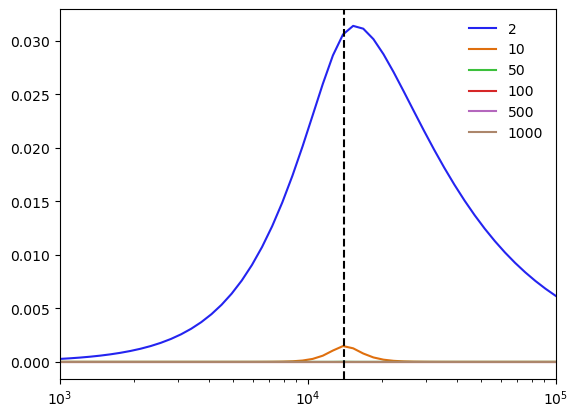

In [28]:
xlim(r_list[0],r_list[-1])
xscale('log')
for j, ell in tqdm.tqdm(enumerate(l_list)):
    plot(r_list,xi[j],label=str(ell))
axvline(rstar,color='k',ls='--')
legend()

0it [00:00, ?it/s]/tmp/ipykernel_703230/1045869470.py:4: RuntimeWarning: invalid value encountered in divide
  plot(r_list,xi[j]/np.max(xi[j]),label=str(ell))
6it [00:00, 2866.27it/s]


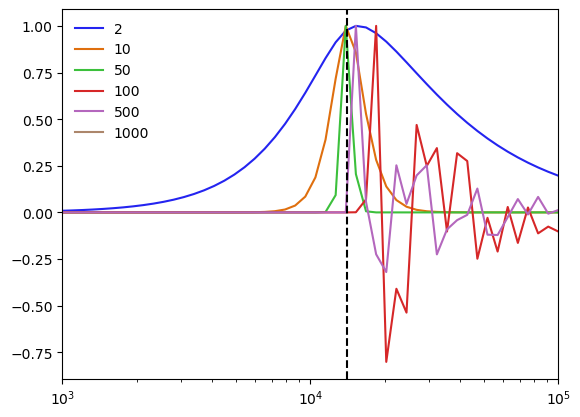

In [29]:
xlim(r_list[0],r_list[-1])
xscale('log')
for j, ell in tqdm.tqdm(enumerate(l_list)):
    plot(r_list,xi[j]/np.max(xi[j]),label=str(ell))
axvline(rstar,color='k',ls='--')
legend()